# LENS Framework: Data Visualization and Statistical Analysis

This notebook provides comprehensive visualisation of scoring results across conditions, models, tasks, and variables with statistical significance testing for the LENS framework.

## Setup and Configuration

In [1]:
# Load required libraries and data
import glob
import matplotlib
# matplotlib.use("pgf")
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
from itertools import combinations

# Configure for LaTeX
plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "pgf.preamble": r"\usepackage[utf8]{inputenc}\usepackage[T1]{fontenc}",
})

# Task
domain_name = 'circuit'

# Figure data groups
context_scaffolding_test_groups = ['condition', 'summariser', 'scorer', 'sample_id']
program_scaffolding_test_groups = ['condition', 'summariser', 'scorer', 'sample_id']
cm_scaffolding_test_groups = ['condition', 'summariser', 'scorer', 'sample_id']

# Load the combined data (assumes data_loading_and_basic_stats.ipynb has been run)
result_path = f'results/{domain_name}'
dst_path = f'plots/{domain_name}'
try:
    combined_df = pd.read_csv(f'{result_path}/lens_multi_sample_analysis.csv')
    print(f"Loaded combined dataset: {len(combined_df)} evaluations")
    print(f"Columns: {list(combined_df.columns)}")
except FileNotFoundError:
    print("Combined data file not found. Please run data_loading_and_basic_stats.ipynb first.")
    combined_df = pd.DataFrame()
    
sns.set_theme(style="whitegrid")
color_set = sns.color_palette("Set3", n_colors=6)
fontsize = 18
labelsize = 20
linewidth = 2
capsize = 0.3
fig_size = (10, 6)
rotation = 0
print('Number of conditions:', len(combined_df['condition'].unique()))

Loaded combined dataset: 3024 evaluations
Columns: ['scorer', 'summariser', 'task_name', 'condition', 'score', 'judgment', 'answer', 'sample_id', 'file_source']
Number of conditions: 14


## Statistical Analysis Functions

Helper functions for conducting statistical significance testing including ANOVA, Tukey's HSD post-hoc tests, and significance visualization.

In [7]:
from scipy.stats import tukey_hsd

def get_significance_stars(p_value):
    """Convert p-value to significance stars"""
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'ns'

def get_significance_threshold(p_value):
    """Convert p-value to significance threshold format"""
    if p_value < 0.001:
        return 'p<0.001'
    elif p_value < 0.01:
        return 'p<0.01'
    elif p_value < 0.05:
        return 'p<0.05'
    else:
        return 'p≥0.05'

def add_significance_bars_tukey(ax, data, x_col, y_col, group_col=None, baseline=None, order=None):
    """Add significance bars with Tukey's HSD post-hoc tests at the bottom of the plot"""
    if group_col is None:
        group_col = x_col
    
    groups = data[group_col].unique() if order is None else order
    
    # First perform ANOVA
    if len(groups) >= 2:
        group_data_lists = [data[data[group_col] == group][y_col].values for group in groups]
        if all(len(group_data) > 1 for group_data in group_data_lists):
            f_stat, p_value_anova = stats.f_oneway(*group_data_lists)
            print(f"\nOne-way ANOVA Results:")
            print(f"F-statistic: {f_stat:.4f}")
            print(f"p-value: {p_value_anova:.6f}")
            print(f"Significant: {'***' if p_value_anova < 0.001 else '**' if p_value_anova < 0.01 else '*' if p_value_anova < 0.05 else 'ns'}")
            
            # Only proceed with post-hoc tests if ANOVA is significant
            if p_value_anova < 0.05:
                # Perform Tukey's HSD test
                try:
                    tukey_result = tukey_hsd(*group_data_lists)
                    print(tukey_result)
                    
                    y_min = data[y_col].min()
                    y_range = data[y_col].max() - data[y_col].min()
                    
                    # Start significance bars below the minimum value
                    height_increment = 0.08 * y_range
                    current_height = y_min - 0.1 * y_range
                    
                    significant_comparisons = 0
                    
                    if baseline and baseline in groups:
                        # Compare each group to baseline
                        baseline_idx = list(groups).index(baseline)
                        baseline_pos = baseline_idx
                        
                        for i, group in enumerate(groups):
                            if group != baseline:
                                # Get Tukey HSD p-value for this comparison
                                p_value = tukey_result.pvalue[baseline_idx, i]
                                
                                if p_value < 0.05:
                                    stars = get_significance_stars(p_value)
                                    
                                    # Draw horizontal line connecting baseline to current group
                                    ax.plot([baseline_pos, i], [current_height, current_height], 
                                           'k-', linewidth=1)
                                    # Draw vertical lines at both ends
                                    ax.plot([baseline_pos, baseline_pos], 
                                           [current_height - 0.01*y_range, current_height + 0.01*y_range], 
                                           'k-', linewidth=1)
                                    ax.plot([i, i], 
                                           [current_height - 0.01*y_range, current_height + 0.01*y_range], 
                                           'k-', linewidth=1)
                                    
                                    # Add significance text in the middle (below the line)
                                    mid_pos = (baseline_pos + i) / 2
                                    ax.text(mid_pos, current_height - 0.015*y_range, stars, 
                                           ha='center', va='top', fontweight='bold', fontsize=fontsize)
                                    
                                    current_height -= height_increment
                                    significant_comparisons += 1
                    else:
                        # Pairwise comparisons for all groups
                        for i in range(len(groups)):
                            for j in range(i + 1, len(groups)):
                                # Get Tukey HSD p-value for this comparison
                                p_value = tukey_result.pvalue[i, j]
                                
                                if p_value < 0.05:
                                    stars = get_significance_stars(p_value)
                                    
                                    # Draw horizontal line connecting the two groups
                                    ax.plot([i, j], [current_height, current_height], 
                                           'k-', linewidth=1)
                                    # Draw vertical lines at both ends
                                    ax.plot([i, i], 
                                           [current_height - 0.01*y_range, current_height + 0.01*y_range], 
                                           'k-', linewidth=1)
                                    ax.plot([j, j], 
                                           [current_height - 0.01*y_range, current_height + 0.01*y_range], 
                                           'k-', linewidth=1)
                                    
                                    # Add significance text in the middle (below the line)
                                    mid_pos = (i + j) / 2
                                    ax.text(mid_pos, current_height - 0.015*y_range, stars, 
                                           ha='center', va='top', fontweight='bold', fontsize=fontsize)
                                    
                                    current_height -= height_increment
                                    significant_comparisons += 1
                    
                    # Adjust y-axis limits to show the significance bars
                    y_lim_bottom = current_height - 0.05 * y_range
                    ax.set_ylim(bottom=y_lim_bottom)
                    
                    return f_stat, p_value_anova, significant_comparisons
                
                except Exception as e:
                    print(f"Warning: Tukey HSD test failed: {e}")
                    return f_stat, p_value_anova, 0
            else:
                return f_stat, p_value_anova, 0
    
    return None, None, 0

def create_condition_palette(conditions, base_colors=None):
    """Create a consistent color palette for specific conditions"""
    if base_colors is None:
        base_colors = sns.color_palette("Set3", n_colors=10)
    
    # Define consistent color mapping for common condition types
    color_mapping = {
        'RM + GC': base_colors[0],
        'RM + GC\n+ LC': base_colors[1], 
        'LENS + LC\n+ AP/NP': base_colors[3],
        'LENS + GC\n+ AP/NP': base_colors[2],
        'TEMPLATE': base_colors[1],
        'RM': base_colors[2],
        'LENS': base_colors[3],
        'RM + NP': base_colors[0],
        'RM + AP': base_colors[1],
        'LENS + NP': base_colors[2],
        'LENS + AP': base_colors[3],
        '1 CM': base_colors[1],
        '2 CMs': base_colors[3],
        '2 CMs \n+ Multi-Responses': base_colors[2],
    }
    
    # Return colors for the specific conditions in order
    return [color_mapping.get(cond) for i, cond in enumerate(conditions)]

## Experimental Condition Comparisons

### Program and Textual Context Analysis
Comparison of reasoning models (RM) vs LENS framework with different context configurations (Global Context, Local Context).


One-way ANOVA Results:
F-statistic: 9.7050
p-value: 0.000004
Significant: ***
Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      0.301     0.376    -0.182     0.784
 (0 - 2)     -0.525     0.007    -0.944    -0.107
 (0 - 3)     -0.264     0.364    -0.682     0.155
 (1 - 0)     -0.301     0.376    -0.784     0.182
 (1 - 2)     -0.826     0.000    -1.245    -0.408
 (1 - 3)     -0.565     0.003    -0.983    -0.146
 (2 - 0)      0.525     0.007     0.107     0.944
 (2 - 1)      0.826     0.000     0.408     1.245
 (2 - 3)      0.262     0.199    -0.080     0.603
 (3 - 0)      0.264     0.364    -0.155     0.682
 (3 - 1)      0.565     0.003     0.146     0.983
 (3 - 2)     -0.262     0.199    -0.603     0.080



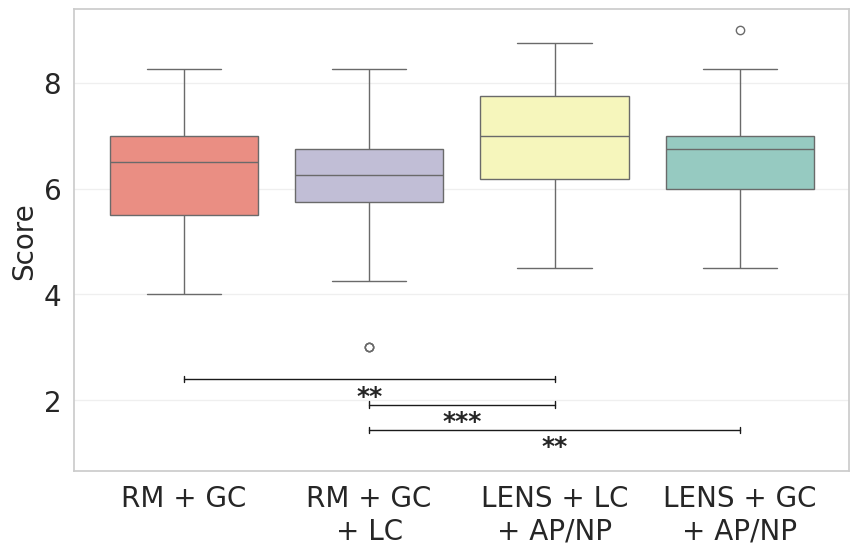

In [8]:
if not combined_df.empty and len(combined_df['sample_id'].unique()) > 1:
    
    # First figure: Condition-related distributions (more compact)
    fig1, axes1 = plt.subplots(1, 1, figsize=fig_size)
    
    # Condition comparison with distribution and significance bars
    condition_stats = combined_df.groupby(context_scaffolding_test_groups)['score'].mean().reset_index()
    
    # Create condition name mapping
    condition_mapping = {
        'rm_global': 'RM + GC',
        'rm_global_local': 'RM + GC\n+ LC',
        'lens_ap_local': 'LENS + LC\n+ AP/NP',
        'lens_np_local': 'LENS + LC\n+ AP/NP',
        'lens_ap_global': 'LENS + GC\n+ AP/NP',
        'lens_np_global': 'LENS + GC\n+ AP/NP'
    }
    
    # Apply mapping to condition names
    condition_stats['plot_condition'] = condition_stats['condition'].map(condition_mapping)
    # Filter out any unmapped conditions
    condition_stats = condition_stats.dropna(subset=['plot_condition'])
    
    ax1 = axes1
    # Define order for plot conditions
    condition_order = ['RM + GC', 
                      'RM + GC\n+ LC', 
                      'LENS + LC\n+ AP/NP', 
                      'LENS + GC\n+ AP/NP']
    # Filter to only include categories that exist in the data
    available_conditions = condition_stats['plot_condition'].unique()
    condition_order = [cat for cat in condition_order if cat in available_conditions]
    
    # Create consistent color palette for these conditions
    condition_colors = create_condition_palette(condition_order)
    
    # Use boxplot
    sns.boxplot(data=condition_stats, y='score', x='plot_condition', hue='plot_condition', legend=False,
                ax=ax1, order=condition_order, palette=condition_colors)
    
    # Add ANOVA and Tukey HSD post-hoc significance bars
    if len(available_conditions) > 1:
        f_stat, p_value_anova, n_sig_comparisons = add_significance_bars_tukey(
            ax1, condition_stats, 'plot_condition', 'score', order=condition_order)

    ax1.set_xlabel('', fontsize=labelsize)
    ax1.set_ylabel('Score', fontsize=labelsize)
    ax1.tick_params(axis='x', labelsize=labelsize, rotation=rotation)
    ax1.tick_params(axis='y', labelsize=labelsize)
    plt.setp(ax1.get_xticklabels(), ha='center')
    ax1.grid(True, alpha=0.3, axis='y')
    plt.savefig(f"{dst_path}/context_scaffolding.pgf")
    plt.savefig(f"{dst_path}/context_scaffolding.png")

### Framework vs Template Baseline Analysis
Comparison between template-based baseline, reasoning models, and LENS framework approaches.

In [11]:
if not combined_df.empty and len(combined_df['sample_id'].unique()) > 1 and combined_df['condition'].str.startswith('template_').any():
    
    # First figure: Condition-related distributions (more compact)
    fig1, axes1 = plt.subplots(1, 1, figsize=fig_size)
    
    # Condition comparison with distribution and significance bars
    condition_stats = combined_df.groupby(context_scaffolding_test_groups)['score'].mean().reset_index()
    
    # Create condition name mapping
    condition_mapping = {
        k: 'RM' if k.startswith('rm_') else 'LENS' for k in condition_stats['condition'].unique() 
    }
    condition_mapping['template_global'] = 'TEMPLATE'
    
    # Apply mapping to condition names
    condition_stats['plot_condition'] = condition_stats['condition'].map(condition_mapping)
    # Filter out any unmapped conditions
    condition_stats = condition_stats.dropna(subset=['plot_condition'])
    
    ax1 = axes1
    # Define order for plot conditions
    condition_order = ['TEMPLATE', 
                      'RM', 
                      'LENS']
    # Filter to only include categories that exist in the data
    available_conditions = condition_stats['plot_condition'].unique()
    condition_order = [cat for cat in condition_order if cat in available_conditions]
    
    # Create consistent color palette for these conditions
    condition_colors = create_condition_palette(condition_order)
    
    # Use boxplot
    sns.boxplot(data=condition_stats, y='score', x='plot_condition', hue='plot_condition', legend=False,
                ax=ax1, order=condition_order, palette=condition_colors)
    
    # Add ANOVA and Tukey HSD post-hoc significance bars
    if len(available_conditions) > 1:
        f_stat, p_value_anova, n_sig_comparisons = add_significance_bars_tukey(
            ax1, condition_stats, 'plot_condition', 'score', order=condition_order)

    ax1.set_xlabel('', fontsize=labelsize)
    ax1.set_ylabel('Score', fontsize=labelsize)
    ax1.tick_params(axis='x', labelsize=labelsize, rotation=rotation)
    ax1.tick_params(axis='y', labelsize=labelsize)
    plt.setp(ax1.get_xticklabels(), ha='center')
    ax1.grid(True, alpha=0.3, axis='y')
    plt.savefig(f"{dst_path}/template.pgf")
    plt.savefig(f"{dst_path}/template.png")

### Program Context Analysis
Comparison of Named Programs (NP) vs Anonymous Programs (AP) across reasoning models and LENS framework.


One-way ANOVA Results:
F-statistic: 21.5567
p-value: 0.000000
Significant: ***
Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      1.398     0.000     0.881     1.916
 (0 - 2)      0.042     0.997    -0.476     0.559
 (0 - 3)      0.296     0.450    -0.221     0.814
 (1 - 0)     -1.398     0.000    -1.916    -0.881
 (1 - 2)     -1.356     0.000    -1.874    -0.839
 (1 - 3)     -1.102     0.000    -1.619    -0.584
 (2 - 0)     -0.042     0.997    -0.559     0.476
 (2 - 1)      1.356     0.000     0.839     1.874
 (2 - 3)      0.255     0.580    -0.263     0.772
 (3 - 0)     -0.296     0.450    -0.814     0.221
 (3 - 1)      1.102     0.000     0.584     1.619
 (3 - 2)     -0.255     0.580    -0.772     0.263



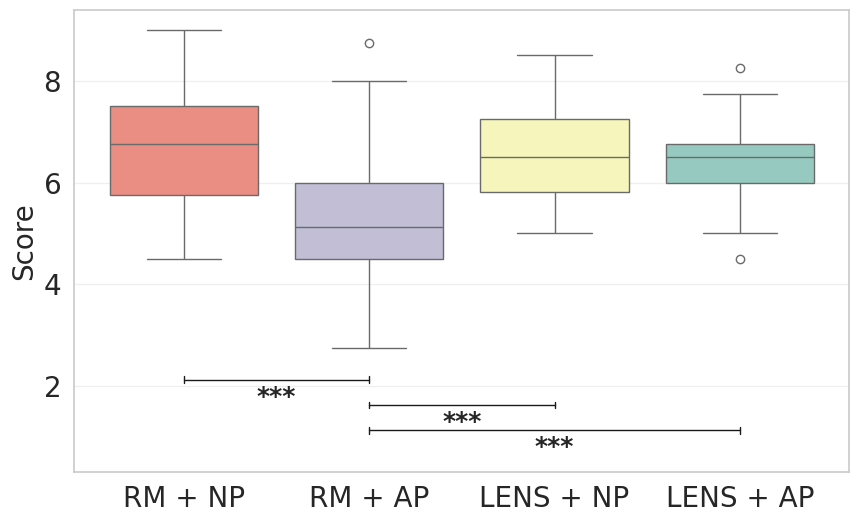

In [10]:
if not combined_df.empty and len(combined_df['sample_id'].unique()) > 1:
    
    # First figure: Condition-related distributions (more compact)
    fig1, axes1 = plt.subplots(1, 1, figsize=fig_size)
    
    # Condition comparison with distribution and significance bars
    condition_stats = combined_df.groupby(program_scaffolding_test_groups)['score'].mean().reset_index()
    
    # Create condition name mapping
    condition_mapping = {
        'rm_np': 'RM + NP',
        'rm_ap': 'RM + AP',
        'lens_np': 'LENS + NP',
        'lens_ap': 'LENS + AP'
    }
    
    # Apply mapping to condition names
    condition_stats['plot_condition'] = condition_stats['condition'].map(condition_mapping)
    # Filter out any unmapped conditions
    condition_stats = condition_stats.dropna(subset=['plot_condition'])
    
    ax1 = axes1
    # Define order for plot conditions
    condition_order = ['RM + NP',
                       'RM + AP',
                       'LENS + NP',
                       'LENS + AP']
    # Filter to only include categories that exist in the data
    available_conditions = condition_stats['plot_condition'].unique()
    condition_order = [cat for cat in condition_order if cat in available_conditions]
    
    # Create consistent color palette for these conditions
    condition_colors = create_condition_palette(condition_order)
    
    # Use boxplot
    sns.boxplot(data=condition_stats, y='score', x='plot_condition', hue='plot_condition', legend=False,
                ax=ax1, order=condition_order, palette=condition_colors)
    
    # Add ANOVA and Tukey HSD post-hoc significance bars
    if len(available_conditions) > 1:
        f_stat, p_value_anova, n_sig_comparisons = add_significance_bars_tukey(
            ax1, condition_stats, 'plot_condition', 'score', order=condition_order)

    ax1.set_xlabel('', fontsize=labelsize)
    ax1.set_ylabel('Score', fontsize=labelsize)
    ax1.tick_params(axis='x', labelsize=labelsize, rotation=rotation)
    ax1.tick_params(axis='y', labelsize=labelsize)
    plt.setp(ax1.get_xticklabels(), ha='center')
    # ax1.set_ylim(0, 10)
    ax1.grid(True, alpha=0.3, axis='y')
    plt.savefig(f"{dst_path}/program_scaffolding.pgf")
    plt.savefig(f"{dst_path}/program_scaffolding.png")

### Coding Model Consensus Analysis
Comparison of single vs multiple coding models and the effect of multi-response generation on interpretation quality.


One-way ANOVA Results:
F-statistic: 15.9441
p-value: 0.000000
Significant: ***
Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.523     0.004    -0.907    -0.140
 (0 - 2)     -0.912     0.000    -1.296    -0.529
 (1 - 0)      0.523     0.004     0.140     0.907
 (1 - 2)     -0.389     0.046    -0.772    -0.005
 (2 - 0)      0.912     0.000     0.529     1.296
 (2 - 1)      0.389     0.046     0.005     0.772



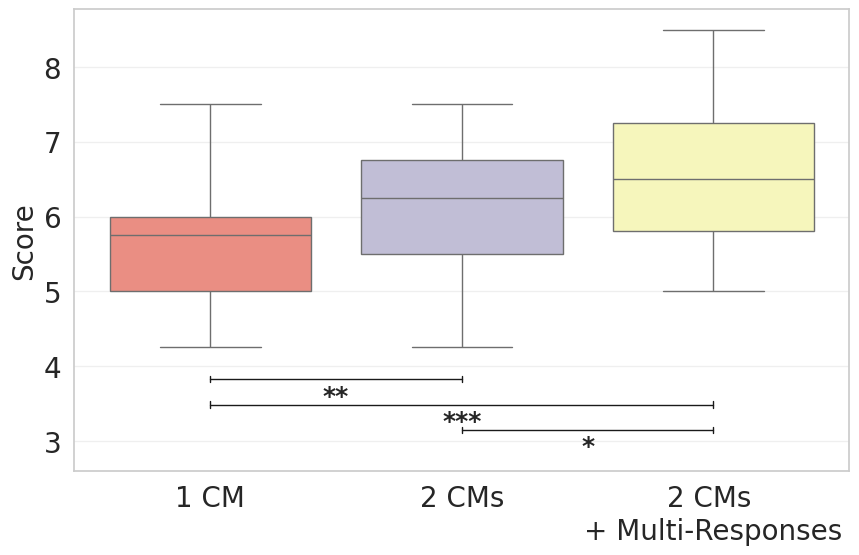

In [ ]:
if not combined_df.empty and len(combined_df['sample_id'].unique()) > 1:
    
    # First figure: Condition-related distributions (more compact)
    fig1, axes1 = plt.subplots(1, 1, figsize=fig_size)
    
    # Condition comparison with distribution and significance bars
    condition_stats = combined_df.groupby(cm_scaffolding_test_groups)['score'].mean().reset_index()
    
    # Create condition name mapping
    condition_mapping = {
        'lens_single_cm': '1 CM',
        'lens_two_cm': '2 CMs',
        'lens_np': '2 CMs \n+ Multi-Responses',
    }
    
    # Apply mapping to condition names
    condition_stats['plot_condition'] = condition_stats['condition'].map(condition_mapping)
    # Filter out any unmapped conditions
    condition_stats = condition_stats.dropna(subset=['plot_condition'])
    
    ax1 = axes1
    # Define order for plot conditions
    condition_order = ['1 CM',
                       '2 CMs',
                       '2 CMs \n+ Multi-Responses']
    # Filter to only include categories that exist in the data
    available_conditions = condition_stats['plot_condition'].unique()
    condition_order = [cat for cat in condition_order if cat in available_conditions]
    
    # Create consistent color palette for these conditions
    condition_colors = create_condition_palette(condition_order)
    
    # Use boxplot
    sns.boxplot(data=condition_stats, y='score', x='plot_condition', hue='plot_condition', legend=False,
                ax=ax1, order=condition_order, palette=condition_colors)
    
    # Add ANOVA and Tukey HSD post-hoc significance bars
    if len(available_conditions) > 1:
        f_stat, p_value_anova, n_sig_comparisons = add_significance_bars_tukey(
            ax1, condition_stats, 'plot_condition', 'score', order=condition_order)

    # ax1.set_ylim(2, 9)
    ax1.set_xlabel('', fontsize=labelsize)
    ax1.set_ylabel('Score', fontsize=labelsize)
    ax1.tick_params(axis='x', labelsize=labelsize, rotation=rotation)
    plt.setp(ax1.get_xticklabels(), ha='center')
    ax1.tick_params(axis='y', labelsize=labelsize)
    ax1.grid(True, alpha=0.3, axis='y')
    plt.savefig(f"{dst_path}/consensus.pgf")
    plt.savefig(f"{dst_path}/consensus.png")